In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, ConcatDataset, random_split
from torchvision import transforms, datasets, models
from torchvision.io import read_image
import torchvision.utils as vutils
import pandas as pd

from torch import nn, optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from google.colab import drive
drive.mount('/content/drive')
save_path = '/content/drive/My Drive/APA/'
output_dir = save_path +'reconstructions_DAE'
os.makedirs(output_dir, exist_ok=True)
print(output_dir)

Mounted at /content/drive
/content/drive/My Drive/APA/reconstructions_DAE


In [2]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(0, 1)])
# Load the MNIST dataset
mnist_dataset_train = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
# Load the test MNIST dataset
mnist_dataset_test = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

batch_size = 128
train_loader = torch.utils.data.DataLoader(
    mnist_dataset_train, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    mnist_dataset_test, batch_size=10, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.2MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.04MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.38MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



#auxiliar

In [ ]:
def save_reconstructions(epoch, model, data_loader, device, add_noise, output_dir=output_dir):
    model.eval()
    os.makedirs(output_dir, exist_ok=True)
    with torch.no_grad():
        for i, (data, labels) in enumerate(data_loader):
            data = data.to(device)
            noisy_data = add_noise(data)
            recon_data = model(noisy_data)
            for j in range(min(5, len(noisy_data))):  #5 pares por época
                original = data[j].cpu().numpy().squeeze()
                noisy = noisy_data[j].cpu().numpy().squeeze()
                reconstructed = recon_data[j].cpu().numpy().squeeze()

                plt.subplot(1, 3, 1)
                plt.title("Original")
                plt.imshow(original, cmap="gray")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.title("Com Ruído")
                plt.imshow(noisy, cmap="gray")
                plt.axis("off")
                plt.subplot(1, 3, 3)
                plt.title("Reconstruído")
                plt.imshow(reconstructed, cmap="gray")
                plt.axis("off")

                plt.savefig(os.path.join(output_dir, f"epoch_{epoch}_pair_{i}_{j}.png"))
                plt.close()

            break

# Reconstruction Function

In [ ]:
def recon_dae(model, data, add_noise, n = 0.5):
    batch_size = 10

    data_iter = iter(data)
    images, labels = next(data_iter)
    current_batch_size = images.size(0)  

    batch_size = min(batch_size, current_batch_size)
    images = images[:batch_size].to(device)
    labels = labels[:batch_size]

    noisy_images = add_noise(images, n)

    model.eval() 
    with torch.no_grad():
        reconstructed = model(noisy_images)

    # Plotar as amostras originais, ruidosas e reconstruídas
    fig, axes = plt.subplots(batch_size, 3, figsize=(12, batch_size * 2)) 

    images = images.cpu()
    noisy_images = noisy_images.cpu()
    reconstructed = reconstructed.cpu()

    for i in range(batch_size):
        # Imagem original com rótulo
        axes[i, 0].imshow(images[i][0].numpy(), cmap='gray')
        axes[i, 0].set_title(f"Original (Label: {labels[i].item()})")
        axes[i, 0].axis('off')

        # Imagem ruidosa
        axes[i, 1].imshow(noisy_images[i][0].numpy(), cmap='gray')
        axes[i, 1].set_title("Imagem Ruidosa")
        axes[i, 1].axis('off')

        # Imagem reconstruída
        axes[i, 2].imshow(reconstructed[i][0].numpy(), cmap='gray')
        axes[i, 2].set_title("Reconstruída")
        axes[i, 2].axis('off')

    plt.show()

# Latent Space

In [ ]:
def latent_space_dae(model, data, add_noise):
    latent_space = []
    labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(data):
            model.eval()

            images, targets = batch
            noisy_images = add_noise(images).to(device)
            z = model.encoder(noisy_images)
            latent_space.append(z)
            labels.append(targets)

    latent_space = torch.cat(latent_space, dim=0).cpu().numpy()
    labels = torch.cat(labels, dim=0).cpu().numpy()

    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42)
    latent_tsne = tsne.fit_transform(latent_space)

    plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=labels, cmap='viridis')
    plt.colorbar()
    plt.title("t-SNE Visualization of Latent Space (DAE)")
    plt.show()

# DAE

In [6]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(7 * 7 * 256, latent_dim)

        # Funções de ativação
        self.leaky_relu = nn.LeakyReLU(0.02)
        self.selu = nn.SELU()

    def forward(self, x):
        x = self.leaky_relu(self.conv1(x))
        x = self.bn1(x)
        x = self.leaky_relu(self.conv2(x))
        x = self.bn2(x)
        x = self.leaky_relu(self.conv3(x))
        x = self.bn3(x)
        x = self.leaky_relu(self.conv4(x))
        x = self.bn4(x)
        x = self.flatten(x)
        x = self.selu(self.fc(x))
        return x

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 7 * 7 * 256)
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.deconv4 = nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1)

        # Funções de ativação
        self.leaky_relu = nn.LeakyReLU(0.02)
        self.selu = nn.SELU()

    def forward(self, z):
        x = self.selu(self.fc(z))
        x = x.view(-1, 256, 7, 7)
        x = self.leaky_relu(self.deconv1(x))
        x = self.bn1(x)
        x = self.leaky_relu(self.deconv2(x))
        x = self.bn2(x)
        x = self.leaky_relu(self.deconv3(x))
        x = self.bn3(x)
        x = torch.sigmoid(self.deconv4(x))
        return x


class DAE(nn.Module):
    def __init__(self, latent_dim):
        super(DAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed

# Função de perda para o Autoencoder (MSE)
def loss_function(recon_x, x):
    return nn.functional.mse_loss(recon_x, x)


In [7]:
def add_noise (data , noise_factor =0.5) :
    noisy_data = data + noise_factor * torch.randn_like( data )
    return torch.clamp( noisy_data , 0., 1.)

# Train

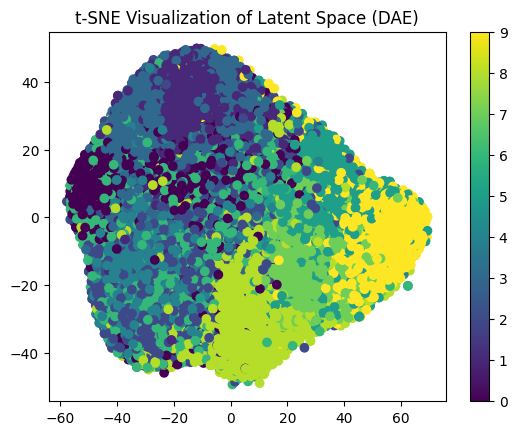

In [8]:
model = []
model = DAE(latent_dim=256).to(device)
num_epochs = 50
optimizer = optim.Adam(model.parameters(), lr=0.0001)

latent_space_dae(model, train_loader, add_noise)

In [9]:
for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data = data.to(device)

            noisy_data = add_noise(data)

            optimizer.zero_grad()
            recon_batch = model(noisy_data)
            loss = loss_function(recon_batch, data)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()

        average_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}")

        if epoch in [0, 5, 10, 15, 20, num_epochs - 1]:
            save_reconstructions(epoch, model, train_loader, device, add_noise)

Epoch 1/50, Loss: 0.0374
Epoch 2/50, Loss: 0.0195
Epoch 3/50, Loss: 0.0167
Epoch 4/50, Loss: 0.0154
Epoch 5/50, Loss: 0.0146
Epoch 6/50, Loss: 0.0140
Epoch 7/50, Loss: 0.0136
Epoch 8/50, Loss: 0.0133
Epoch 9/50, Loss: 0.0130
Epoch 10/50, Loss: 0.0128
Epoch 11/50, Loss: 0.0127
Epoch 12/50, Loss: 0.0125
Epoch 13/50, Loss: 0.0124
Epoch 14/50, Loss: 0.0123
Epoch 15/50, Loss: 0.0121
Epoch 16/50, Loss: 0.0121
Epoch 17/50, Loss: 0.0120
Epoch 18/50, Loss: 0.0119
Epoch 19/50, Loss: 0.0118
Epoch 20/50, Loss: 0.0117
Epoch 21/50, Loss: 0.0117
Epoch 22/50, Loss: 0.0116
Epoch 23/50, Loss: 0.0115
Epoch 24/50, Loss: 0.0115
Epoch 25/50, Loss: 0.0114
Epoch 26/50, Loss: 0.0114
Epoch 27/50, Loss: 0.0113
Epoch 28/50, Loss: 0.0113
Epoch 29/50, Loss: 0.0112
Epoch 30/50, Loss: 0.0112
Epoch 31/50, Loss: 0.0111
Epoch 32/50, Loss: 0.0111
Epoch 33/50, Loss: 0.0111
Epoch 34/50, Loss: 0.0111
Epoch 35/50, Loss: 0.0110
Epoch 36/50, Loss: 0.0110
Epoch 37/50, Loss: 0.0109
Epoch 38/50, Loss: 0.0109
Epoch 39/50, Loss: 0.

# Reconstruction

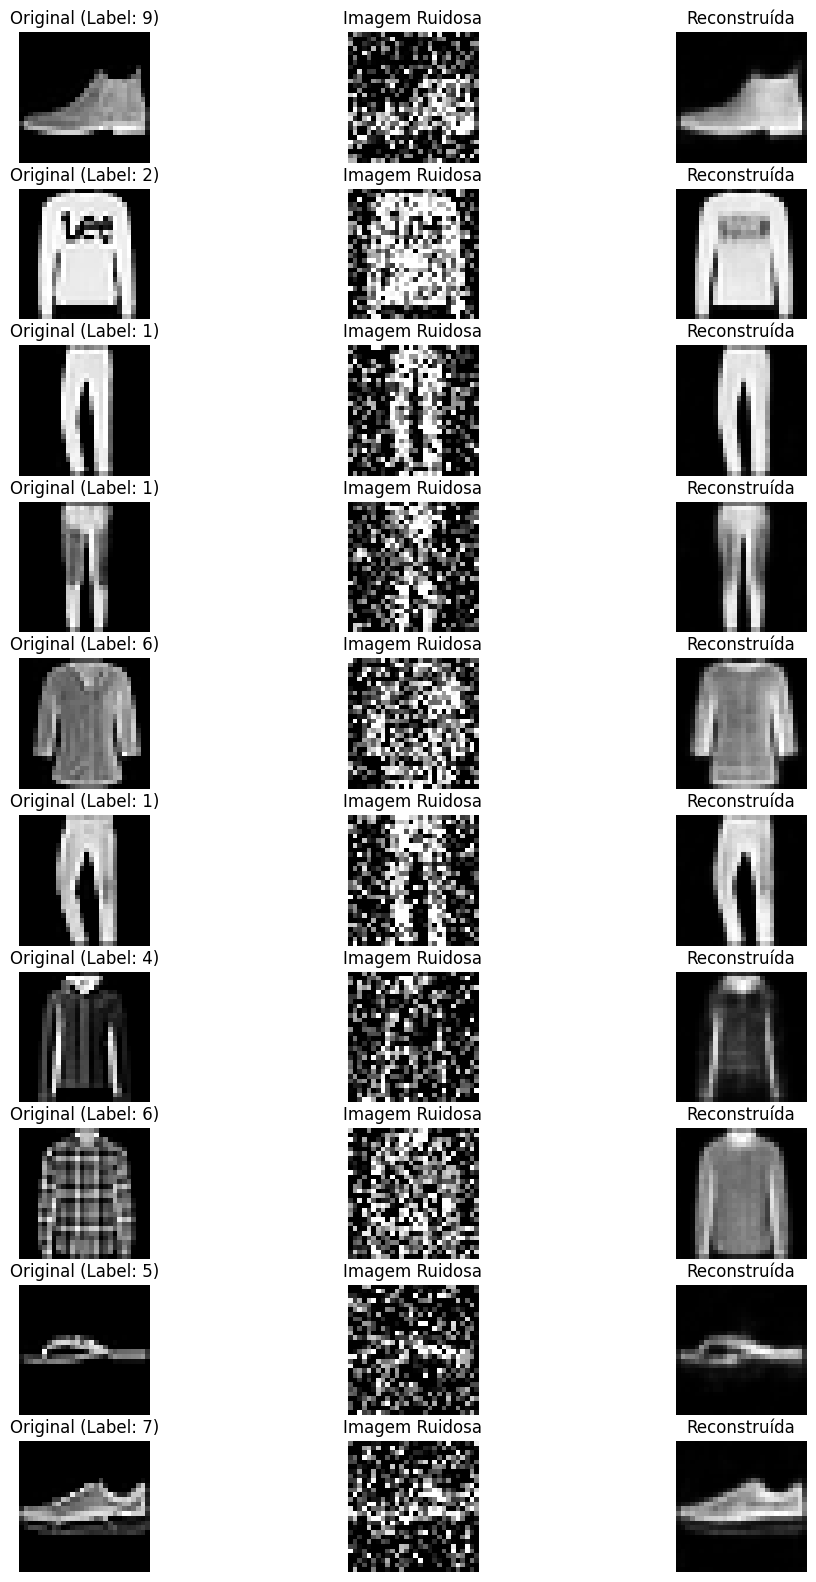

In [10]:
recon_dae(model, test_loader, add_noise)

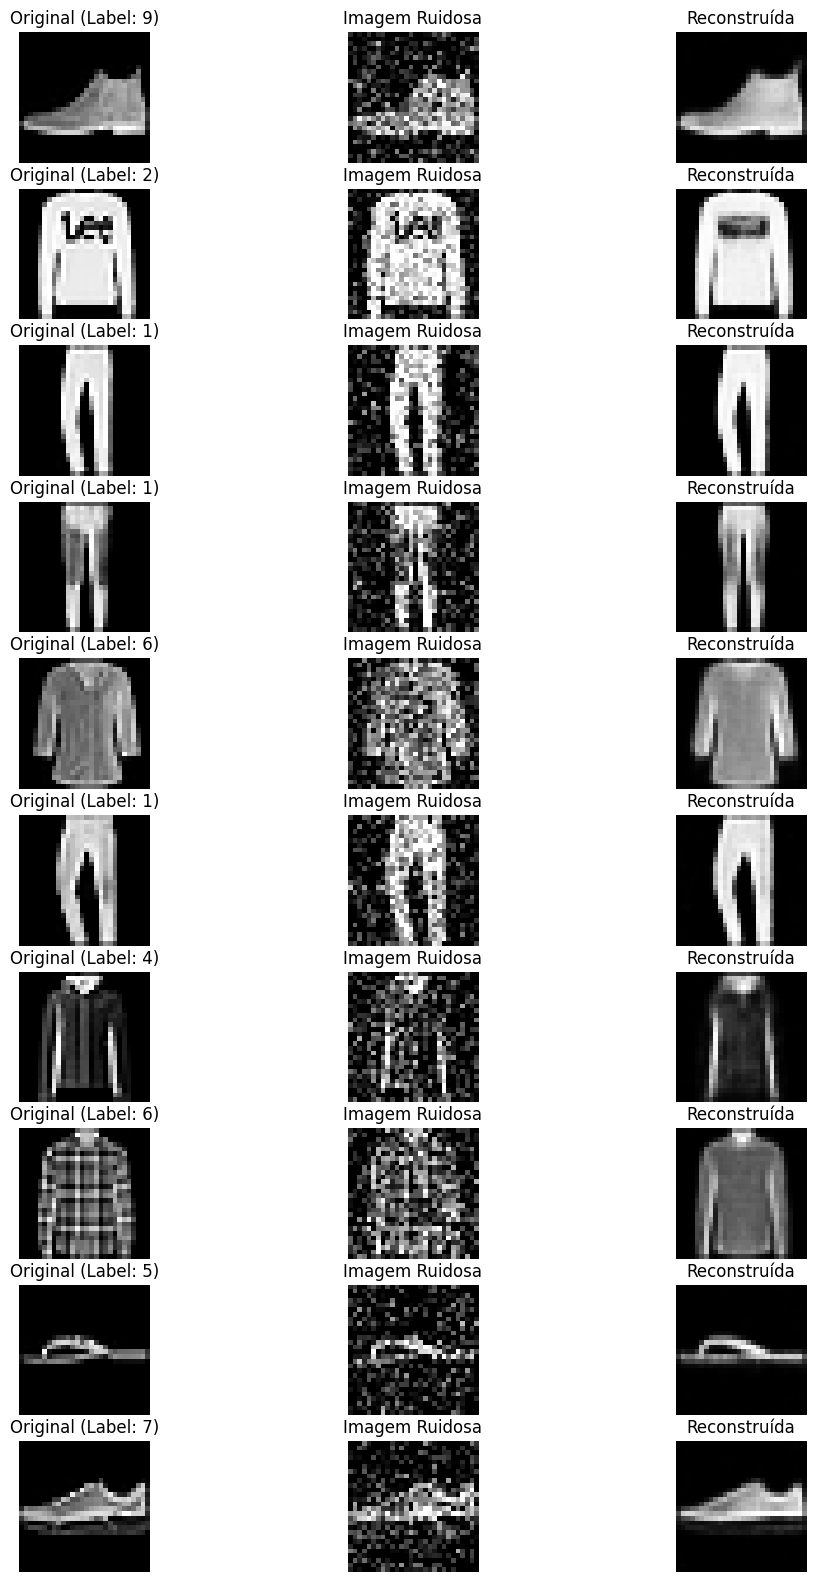

In [11]:
recon_dae(model, test_loader, add_noise, n = 0.25)

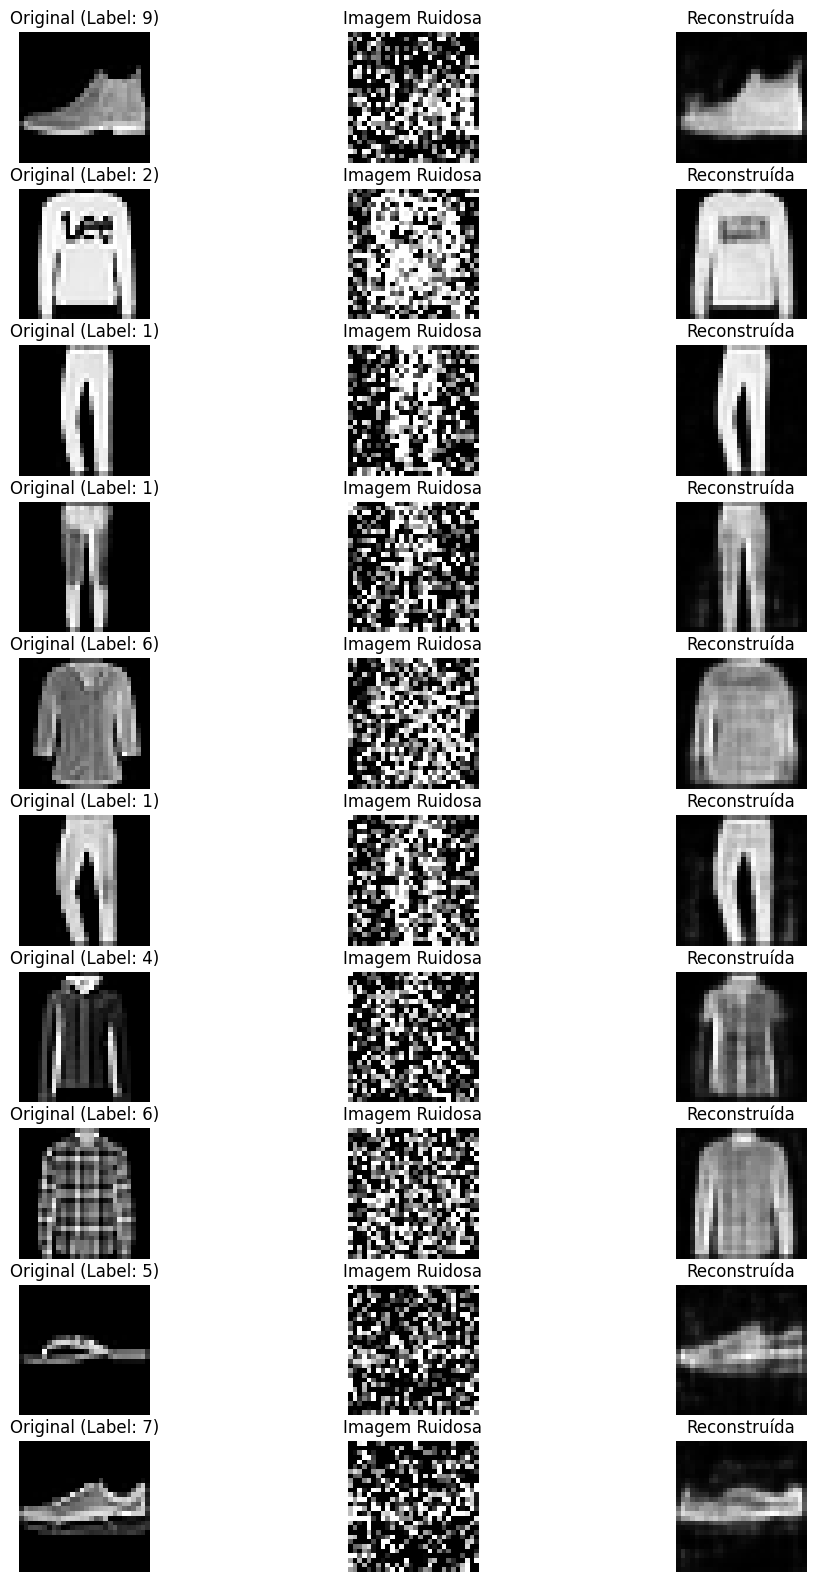

In [12]:
recon_dae(model, test_loader, add_noise, n = 0.75)

# Latent Space (t_SNE)

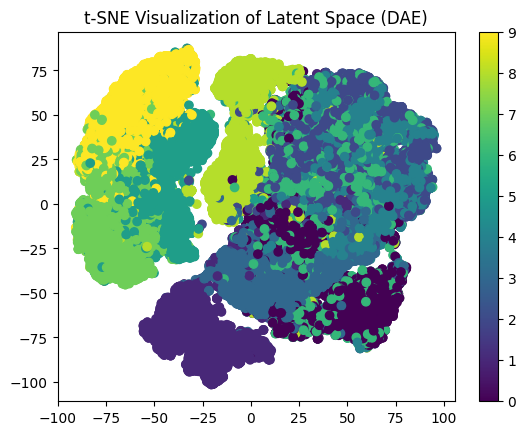

In [13]:
latent_space_dae(model, train_loader, add_noise)

# Transfer Learning

In [14]:
# Train the model
def train_classifier(model, train_loader, val_loader, criterion, optimizer, num_epochs, add_noise, device=device):

  train_losses = []
  train_accs = []
  val_losses = []
  val_accs = []

  model.to(device)

  for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

      images, labels = images.to(device), labels.to(device)
      noisy_img = add_noise(images)
      optimizer.zero_grad()

      outputs = model(noisy_img)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()

      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    train_loss = running_loss/len(train_loader)
    train_acc = 100 * correct / total

    #Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
      for images, labels in val_loader:

        images, labels = images.to(device), labels.to(device)
        noisy_img = add_noise(images)

        outputs = model(noisy_img)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    val_loss = val_loss/len(val_loader)
    val_acc = 100 * correct / total

    print(f'Epoch [{epoch + 1}/{num_epochs}], 'f'Train_Loss: {train_loss:.4f}, ' f'Train_Acc: {train_acc:.2f}%, '
            f'Val_Loss: {val_loss:.4f}, 'f'Val_Acc: {val_acc:.2f}%')

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

  print('Finished Training')

  return model, train_losses, train_accs, val_losses, val_accs

In [15]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score,  mean_squared_error, r2_score, f1_score, precision_score, recall_score
import seaborn as sns

def evaluate_network(model,dataset_loader, to_device=True):
    # X given input data
    # y corresponding target labels
    full_dataset = []
    for batch in dataset_loader:
        # Assuming each batch is a tuple (inputs, labels)
        inputs, labels = batch
        noisy_inputs = add_noise(inputs)
        full_dataset.append((noisy_inputs, labels))

        # Concatenate all data points into a single tensor
        X = torch.cat([noisy_inputs for noisy_inputs, _ in full_dataset], dim=0)
        y = torch.cat([labels for _, labels in full_dataset], dim=0)


    # Set the model to evaluation mode
    model.eval()

    if to_device:
      # Assuming you're using GPU (if available)
        #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        X = X.to(device)
        y = y.to(device)
        #model = model.to(device)

    # Run the model on the test data
    with torch.no_grad():
        outputs = model(X)
        _, predicted = torch.max(outputs.data, 1)

    # Convert tensors to numpy arrays
    if to_device:
        predicted = predicted.to("cpu")

    predicted_np = predicted.cpu().numpy()
    test_target_np = y.cpu().numpy()


    # confusion matrix
    conf_mat = confusion_matrix(test_target_np, predicted_np)
    # f1 score
    f1 = f1_score(test_target_np, predicted_np, average='weighted')
    # precision
    precision = precision_score(test_target_np, predicted_np, average='weighted')
    # recall
    recall = recall_score(test_target_np, predicted_np, average='weighted')
    # balanced accuracy
    bal_acc = balanced_accuracy_score(y.cpu(), predicted_np)
    # mean_Class accuracy
    class_accuracy = conf_mat.diagonal() / conf_mat.sum(axis=1)
    mean_class_accuracy = class_accuracy.mean()

    #print('Confusion Matrix:\n', conf_mat)
    print('Evaluation Metrics')
    print(f"F1 score: {f1}, Precision: {precision}, Recall: {recall}, Balanced Accuracy: {bal_acc}, Mean-Class Accuracy: {mean_class_accuracy}")
    print(f"per class: [1] {class_accuracy[0]}, [2] {class_accuracy[1]}, [3] {class_accuracy[2]}, [4] {class_accuracy[3]}, [5] {class_accuracy[4]}, \n           [6] {class_accuracy[5]}, [7] {class_accuracy[6]}, [8] {class_accuracy[7]}, [9] {class_accuracy[8]}, [10] {class_accuracy[9]}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=[f'Class {i+1}' for i in range(conf_mat.shape[1])],
                yticklabels=[f'Class {i+1}' for i in range(conf_mat.shape[0])])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return mean_class_accuracy

In [ ]:
class DAE_Classifier(nn.Module):
    def __init__(self, pretrained_encoder, latent_dim, num_classes):
        super(DAE_Classifier, self).__init__()

        self.encoder = pretrained_encoder
        self.classifier = nn.Linear(latent_dim, num_classes)

        #congelar os parâmetros do encoder
        for param in self.encoder.parameters():
            param.requires_grad = False 

    def forward(self, x):
        z = self.encoder(x)
        logits = self.classifier(z)
        return logits

In [17]:
#validation and training set
ratio_split = 0.8
train_size = int(ratio_split * len(mnist_dataset_train))  # 80% para treino
val_size = len(mnist_dataset_train) - train_size  # 20% para validação

train_dataset, val_dataset = random_split(mnist_dataset_train, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [18]:
learning_rate = 0.001
num_epochs = 5
batch_size = 32
wd = 0.0001

# new model with classification layer
classifier = DAE_Classifier(pretrained_encoder=model.encoder, latent_dim=256, num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=learning_rate, weight_decay=wd)

classifier, train_losses, train_accs, val_losses, val_accs = train_classifier(classifier, train_loader, val_loader, criterion, optimizer, num_epochs, add_noise, device=device)

Epoch [1/5], Train_Loss: 0.7102, Train_Acc: 76.39%, Val_Loss: 0.5151, Val_Acc: 81.45%
Epoch [2/5], Train_Loss: 0.4932, Train_Acc: 81.91%, Val_Loss: 0.5070, Val_Acc: 81.22%
Epoch [3/5], Train_Loss: 0.4701, Train_Acc: 82.51%, Val_Loss: 0.4732, Val_Acc: 82.38%
Epoch [4/5], Train_Loss: 0.4680, Train_Acc: 82.64%, Val_Loss: 0.4781, Val_Acc: 81.96%
Epoch [5/5], Train_Loss: 0.4626, Train_Acc: 82.72%, Val_Loss: 0.4958, Val_Acc: 81.62%
Finished Training


Evaluation Metrics
F1 score: 0.8157455342910871, Precision: 0.823567896752076, Recall: 0.8151, Balanced Accuracy: 0.8150999999999999, Mean-Class Accuracy: 0.8150999999999999
per class: [1] 0.792, [2] 0.961, [3] 0.544, [4] 0.83, [5] 0.731, 
           [6] 0.92, [7] 0.61, [8] 0.904, [9] 0.97, [10] 0.889


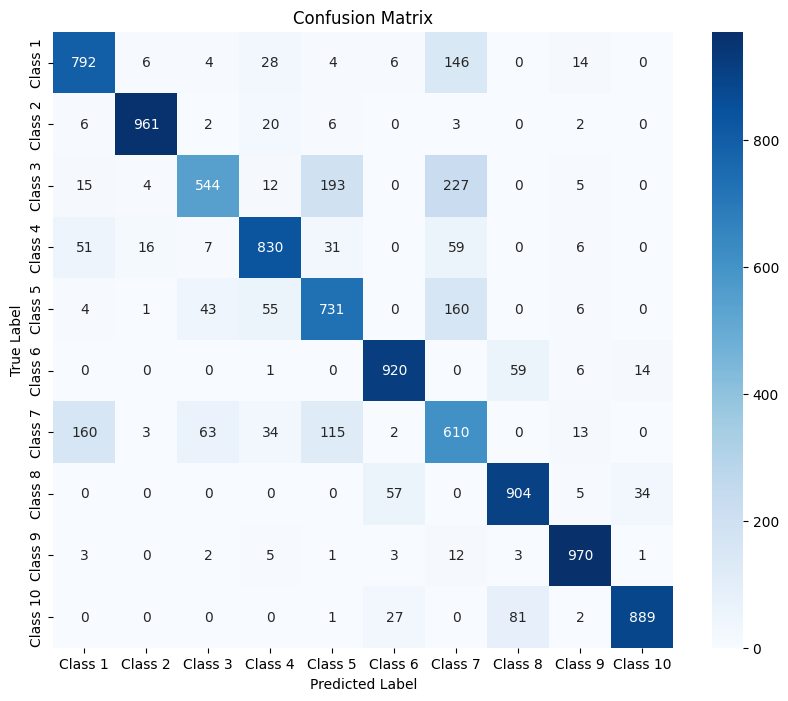

In [19]:
mCA = evaluate_network(classifier, test_loader)

#Without Noise

In [20]:
# Train the model
def train_classifier_no_noise(model, train_loader, val_loader, criterion, optimizer, num_epochs, add_noise, device=device):

  train_losses = []
  train_accs = []
  val_losses = []
  val_accs = []

  model.to(device)

  for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()

      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()

      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

    train_loss = running_loss/len(train_loader)
    train_acc = 100 * correct / total

    #Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
      for images, labels in val_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    val_loss = val_loss/len(val_loader)
    val_acc = 100 * correct / total

    print(f'Epoch [{epoch + 1}/{num_epochs}], 'f'Train_Loss: {train_loss:.4f}, ' f'Train_Acc: {train_acc:.2f}%, '
            f'Val_Loss: {val_loss:.4f}, 'f'Val_Acc: {val_acc:.2f}%')

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

  print('Finished Training')

  return model, train_losses, train_accs, val_losses, val_accs

In [21]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score,  mean_squared_error, r2_score, f1_score, precision_score, recall_score
import seaborn as sns

def evaluate_network_no_noise(model,dataset_loader, to_device=True):
    # X given input data
    # y corresponding target labels
    full_dataset = []
    for batch in dataset_loader:
        # Assuming each batch is a tuple (inputs, labels)
        inputs, labels = batch
        full_dataset.append((inputs, labels))

        # Concatenate all data points into a single tensor
        X = torch.cat([inputs for inputs, _ in full_dataset], dim=0)
        y = torch.cat([labels for _, labels in full_dataset], dim=0)


    # Set the model to evaluation mode
    model.eval()

    if to_device:
      # Assuming you're using GPU (if available)
        #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        X = X.to(device)
        y = y.to(device)
        #model = model.to(device)

    # Run the model on the test data
    with torch.no_grad():
        outputs = model(X)
        _, predicted = torch.max(outputs.data, 1)

    # Convert tensors to numpy arrays
    if to_device:
        predicted = predicted.to("cpu")

    predicted_np = predicted.cpu().numpy()
    test_target_np = y.cpu().numpy()


    # confusion matrix
    conf_mat = confusion_matrix(test_target_np, predicted_np)
    # f1 score
    f1 = f1_score(test_target_np, predicted_np, average='weighted')
    # precision
    precision = precision_score(test_target_np, predicted_np, average='weighted')
    # recall
    recall = recall_score(test_target_np, predicted_np, average='weighted')
    # balanced accuracy
    bal_acc = balanced_accuracy_score(y.cpu(), predicted_np)
    # mean_Class accuracy
    class_accuracy = conf_mat.diagonal() / conf_mat.sum(axis=1)
    mean_class_accuracy = class_accuracy.mean()

    #print('Confusion Matrix:\n', conf_mat)
    print('Evaluation Metrics')
    print(f"F1 score: {f1}, Precision: {precision}, Recall: {recall}, Balanced Accuracy: {bal_acc}, Mean-Class Accuracy: {mean_class_accuracy}")
    print(f"per class: [1] {class_accuracy[0]}, [2] {class_accuracy[1]}, [3] {class_accuracy[2]}, [4] {class_accuracy[3]}, [5] {class_accuracy[4]}, \n           [6] {class_accuracy[5]}, [7] {class_accuracy[6]}, [8] {class_accuracy[7]}, [9] {class_accuracy[8]}, [10] {class_accuracy[9]}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=[f'Class {i+1}' for i in range(conf_mat.shape[1])],
                yticklabels=[f'Class {i+1}' for i in range(conf_mat.shape[0])])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return mean_class_accuracy

In [22]:
learning_rate = 0.001
num_epochs = 5
batch_size = 32
wd = 0.0001

# new model with classification layer
classifier_no_noise = DAE_Classifier(pretrained_encoder=model.encoder, latent_dim=256, num_classes=10)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier_no_noise.parameters(), lr=learning_rate, weight_decay=wd)

classifier_no_noise, train_losses, train_accs, val_losses, val_accs = train_classifier_no_noise(classifier_no_noise, train_loader, val_loader, criterion, optimizer, num_epochs, add_noise, device=device)

Epoch [1/5], Train_Loss: 0.5971, Train_Acc: 81.09%, Val_Loss: 0.4094, Val_Acc: 85.65%
Epoch [2/5], Train_Loss: 0.3788, Train_Acc: 86.43%, Val_Loss: 0.3760, Val_Acc: 86.42%
Epoch [3/5], Train_Loss: 0.3533, Train_Acc: 87.31%, Val_Loss: 0.3728, Val_Acc: 86.67%
Epoch [4/5], Train_Loss: 0.3438, Train_Acc: 87.60%, Val_Loss: 0.3637, Val_Acc: 86.98%
Epoch [5/5], Train_Loss: 0.3388, Train_Acc: 87.76%, Val_Loss: 0.3561, Val_Acc: 87.54%
Finished Training


Evaluation Metrics
F1 score: 0.8646544371740692, Precision: 0.8677476591597326, Recall: 0.8668, Balanced Accuracy: 0.8668000000000001, Mean-Class Accuracy: 0.8668000000000001
per class: [1] 0.87, [2] 0.962, [3] 0.738, [4] 0.875, [5] 0.859, 
           [6] 0.954, [7] 0.525, [8] 0.96, [9] 0.971, [10] 0.954


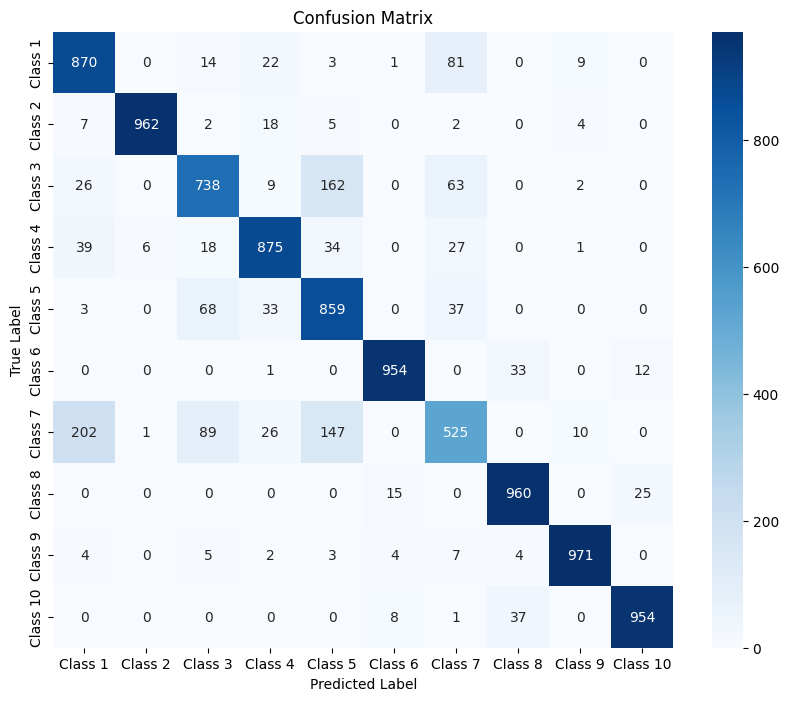

In [23]:
mCA = evaluate_network_no_noise(classifier_no_noise, test_loader)